In [1]:
import matplotlib.pyplot as plt
from torch.profiler import profile, ProfilerActivity
from cubes import get_cube
from utils import profile_and_capture

In [2]:
device = "cpu"
order = "1"
results = {}

In [3]:
print("|  N  |     DOFs |     Setup | FWD Solve | BWD Solve |   Peak RAM |")
print("| --- | -------- | --------- | --------- | --------- | ---------- |")

for N in [10, 20, 30, 40, 50, 60, 70, 80]:
    cmd = ["python", "cubes.py", "-N", str(N), "-device", device, "-order", order]
    mem_data, internal_clock = profile_and_capture(cmd, device)
    mem_usage = [r for _, r, _ in mem_data]
    setup_t = internal_clock["SETUP_DONE"] - internal_clock["START"]
    fwd_t = internal_clock["FWD_DONE"] - internal_clock["SETUP_DONE"]
    bwd_t = internal_clock["BWD_DONE"] - internal_clock["FWD_DONE"]
    print(
        f"| {N:3d} | {3*N**3:8d} | {setup_t:8.2f}s | {fwd_t:8.2f}s | {bwd_t:8.2f}s "
        f"| {max(mem_usage):8.1f}MB |"
    )
    results[N] = (mem_data, internal_clock)

|  N  |     DOFs |     Setup | FWD Solve | BWD Solve |   Peak RAM |
| --- | -------- | --------- | --------- | --------- | ---------- |
|  10 |     3000 |     0.02s |     0.16s |     0.28s |    482.5MB |
|  20 |    24000 |     0.15s |     0.75s |     0.35s |    894.3MB |
|  30 |    81000 |     0.55s |     2.78s |     0.87s |   1773.4MB |
|  40 |   192000 |     1.29s |     7.00s |     1.72s |   2694.7MB |
|  50 |   375000 |     2.87s |    13.49s |     3.30s |   4044.0MB |
|  60 |   648000 |     5.40s |    27.45s |     5.35s |   5352.8MB |
|  70 |  1029000 |     9.49s |    44.75s |     9.23s |   7699.0MB |
|  80 |  1536000 |    14.62s |    73.53s |    19.38s |   9546.9MB |


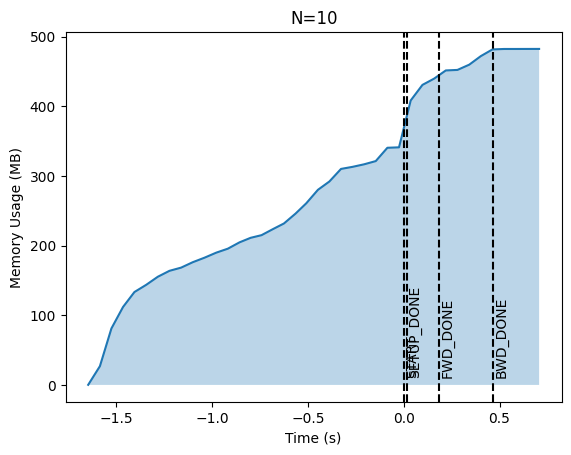

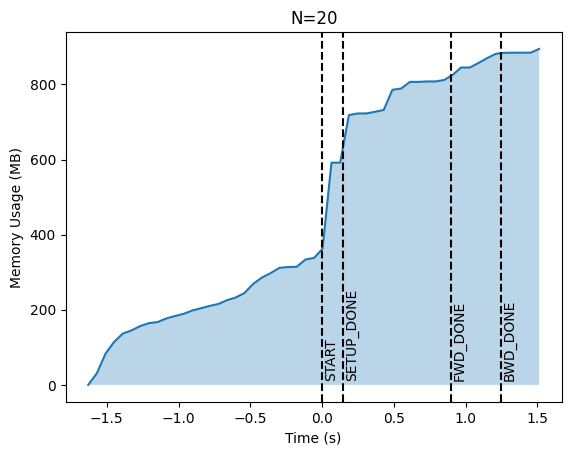

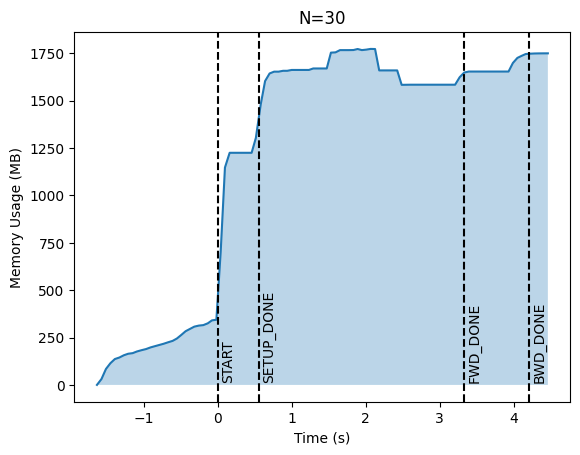

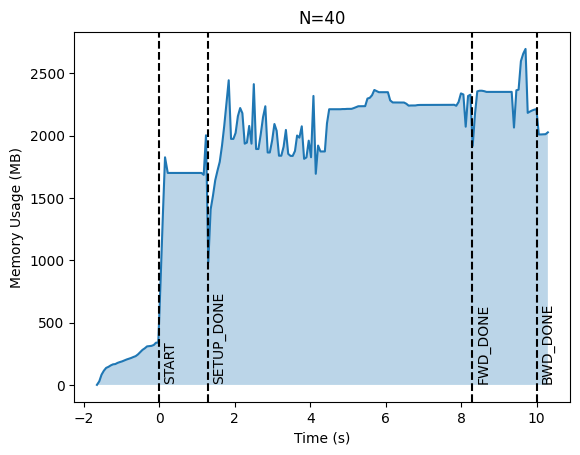

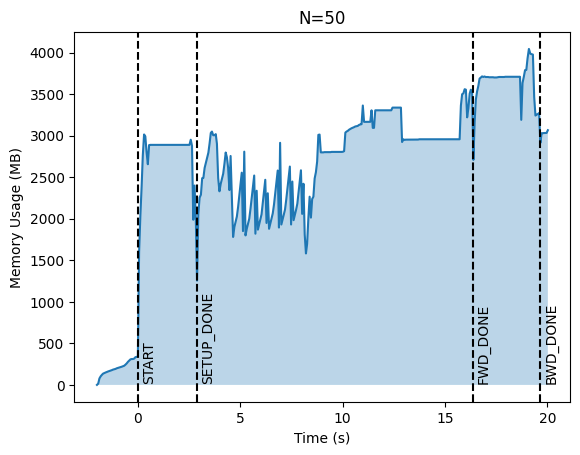

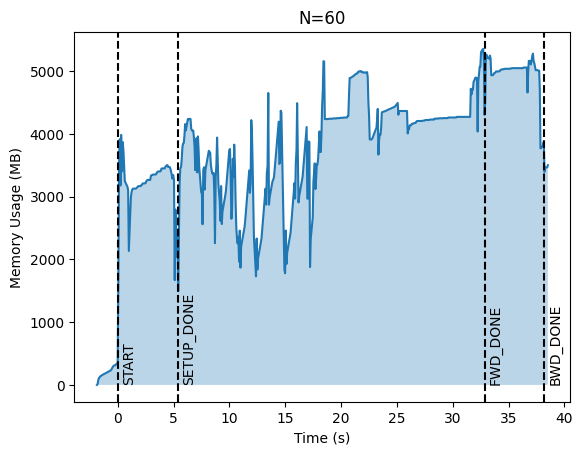

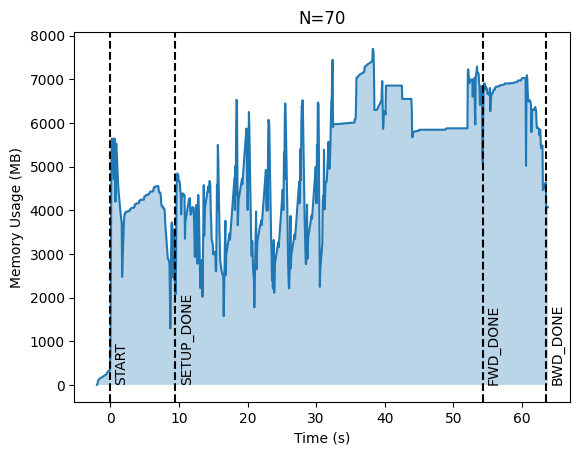

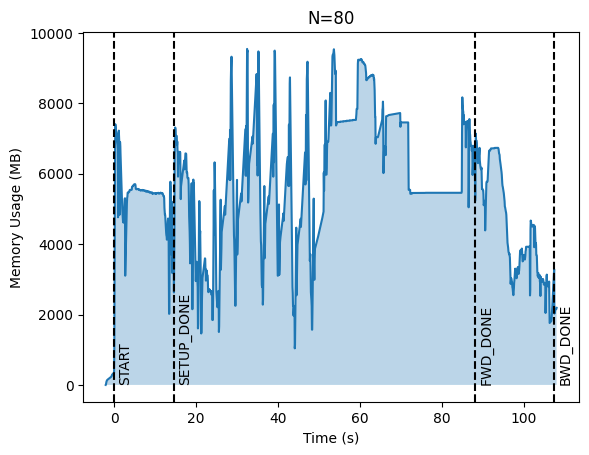

In [4]:
for N, (mem_data, internal_clock) in results.items():
    t0 = internal_clock["START"]
    times = [t - t0 for t, _, _ in mem_data]
    mem_usage = [r for _, r, _ in mem_data]
    plt.plot(times, mem_usage)
    plt.fill_between(times, mem_usage, alpha=0.3)
    for tag, abs_ts in internal_clock.items():
        relative_ts = abs_ts - t0
        plt.axvline(x=relative_ts, color="black", linestyle="--")
        plt.text(
            relative_ts + 0.01 * max(times),
            10,
            tag,
            rotation=90,
            verticalalignment="bottom",
        )
    plt.xlabel("Time (s)")
    plt.ylabel("Memory Usage (MB)")
    plt.title(f"N={N}")
    plt.show()

In [5]:
import cProfile
import pstats


def test():
    cube = get_cube(50)
    cube.solve()


cProfile.run("test()", "stats")
p = pstats.Stats("stats")
print(p.sort_stats("time").print_stats(10))

Sat Apr  4 08:56:35 2026    stats

         30675 function calls (30414 primitive calls) in 16.871 seconds

   Ordered by: internal time
   List reduced from 429 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       80    4.889    0.061    4.889    0.061 {built-in method torch.einsum}
       96    2.290    0.024    2.290    0.024 {built-in method pyamg.amg_core.relaxation.gauss_seidel}
        1    2.200    2.200    2.200    2.200 {built-in method torch._unique2}
       77    1.627    0.021    1.627    0.021 {built-in method scipy.sparse._sparsetools.csr_matvec}
        8    1.385    0.173    1.385    0.173 {built-in method scipy.sparse._sparsetools.bsr_matmat}
        3    0.693    0.231    6.337    2.112 /Users/meyernil/Code/torch-fem/src/torchfem/base.py:607(integrate_material)
      156    0.486    0.003    0.486    0.003 {built-in method scipy.sparse._sparsetools.bsr_matvec}
       39    0.257    0.007    0.257    0.007 {meth

In [6]:
with profile(
    activities=[ProfilerActivity.CPU],
    profile_memory=True,
    record_shapes=True,
) as prof:
    cube = get_cube(20)
    solution = cube.solve()


# Export trace to Chrome Trace format (this can be opened in chrome://tracing or https://ui.perfetto.dev/)
prof.export_chrome_trace("trace.json")
# Print profiler results
print(prof.key_averages().table(sort_by="cpu_memory_usage", row_limit=10))

/Users/meyernil/miniforge3/envs/torchfem/lib/python3.10/site-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


--------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                              Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
--------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                      aten::einsum         0.36%       5.030ms        51.10%     713.623ms       8.920ms     579.45 MB    -181.27 MB            80  
                                         aten::mul         1.66%      23.210ms         1.68%      23.465ms      80.912us     564.24 MB     562.57 MB           290  
                                       aten::empty         0.02%     317.371us         0.02%     317.371us       2.061us     520.43 MB     520.43 MB           154  
          